# Лабораторна робота No 1
## Первинна обробка та представлення мультимедійних даних
Мета: дослідити способи цифрового представлення, кодування та попередньої обробки
зображень і відео.

### Основні завдання
• Завантажити зображення у форматах JPG, PNG, BMP.  
• Дослідити RGB, Grayscale, HSV, YCbCr.  
• Виконати масштабування, поворот, обрізання.  
• Дослідити JPEG-компресію.  
• Обчислити MSE, RMSE, PSNR, SSIM.  
### Дослідницька складова
Провести експеримент із різними рівнями JPEG-компресії:
Q = {10, 20, 40, 60, 80, 95}  
Дослідити залежність:
PSNR = f(Q), SSIM = f(Q)

### Дослідницькі питання
• При якому рівні компресії втрата якості стає суттєвою?  
• Чи однаково змінюються PSNR та SSIM?  
• Який колірний простір краще підходить для певного типу обробки?  
• Як зміна роздільної здатності впливає на якість?  
#### Результат: *таблиця експериментів, графіки та обґрунтований висновок*.  
---

### Завантажуємо зображення в форматі BMP.

Інформація про зображення:

Файл: puppy.bmp
Тип файлу: BMP
Розмірність: 1920 × 1920 пікселів
Колірний режим: RGBA
Розмір файлу: 14745722 Б / 14.06 МБ


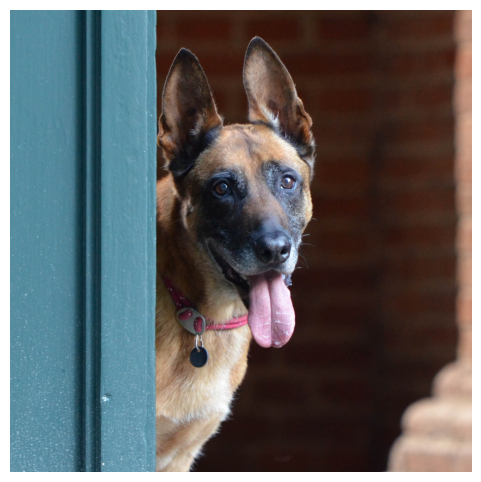

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

file_name = "puppy.bmp"
image_bgr = cv2.imread(file_name, cv2.IMREAD_UNCHANGED)

# Визначення кількості каналів та колірного режиму
if image_bgr.ndim == 2:
    channels = 1
    mode = "L"
    image = image_bgr
elif image_bgr.shape[2] == 4:
    channels = 4
    mode = "RGBA"
    image = cv2.cvtColor(image_bgr, cv2.COLOR_BGRA2RGBA)
else:
    channels = 3
    mode = "RGB"
    image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Інформація про зображення
file_format = os.path.splitext(file_name)[1][1:].upper()
height, width = image.shape[:2]
file_size = os.path.getsize(file_name)

# Виведення інформації
print("Інформація про зображення:\n")
print(f"Файл: {file_name}")
print(f"Тип файлу: {file_format}")
print(f"Розмірність: {width} × {height} пікселів")
print(f"Колірний режим: {mode}")
print(f"Розмір файлу: {file_size} Б / {(file_size/1024/1024):.2f} МБ")

# Виведення зображення
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray" if channels == 1 else None)
plt.axis("off")
plt.show()


### Переводимо в формати .png і .jpg

In [6]:
# Перетворення та збереження у PNG та JPG

def to_bgr(rgb_image):
    """Конвертує RGB(A)/Grayscale масив у формат BGR(A) для cv2.imwrite."""
    if rgb_image.ndim == 2:
        return rgb_image
    if rgb_image.shape[-1] == 4:
        return cv2.cvtColor(rgb_image, cv2.COLOR_RGBA2BGRA)
    return cv2.cvtColor(rgb_image, cv2.COLOR_RGB2BGR)

# PNG зберігає альфа-канал (стиснення без втрат)
cv2.imwrite("puppy.png", to_bgr(image))

# JPEG не підтримує прозорість, тому прибираємо альфа-канал перед збереженням
image_no_alpha = image[..., :3] if (image.ndim == 3 and image.shape[-1] == 4) else image
cv2.imwrite("puppy.jpg", to_bgr(image_no_alpha))

# Отримання розмірів файлів
bmp_size = os.path.getsize("puppy.bmp")
png_size = os.path.getsize("puppy.png")
jpg_size = os.path.getsize("puppy.jpg")

# Виведення результатів
print("Розміри файлів:\n")
print(f"BMP: {(bmp_size/1024/1024):.2f} МБ")
print(f"PNG: {(png_size/1024/1024):.2f} МБ")
print(f"JPG: {(jpg_size/1024/1024):.2f} МБ")


Розміри файлів:

BMP: 14.06 МБ
PNG: 4.72 МБ
JPG: 0.73 МБ


### Теоретичний розмір файлу:
S = W·H·c·b/8 = 1920·1920·4·8/8 = 14745600 Б = 14.06 МБ  
*Це якраз розмір нашого BMP файлу (що і логічно, бо він не стискає дані)*

### RGB and Grayscale
Розкладаємо картинку на канали, порівнюємо теоретичну формулу для обчислення значення яскравості та вбудовану функцію.  
Різниця значень теоретичного і вбудованого обчислення яскравості практично нульова.

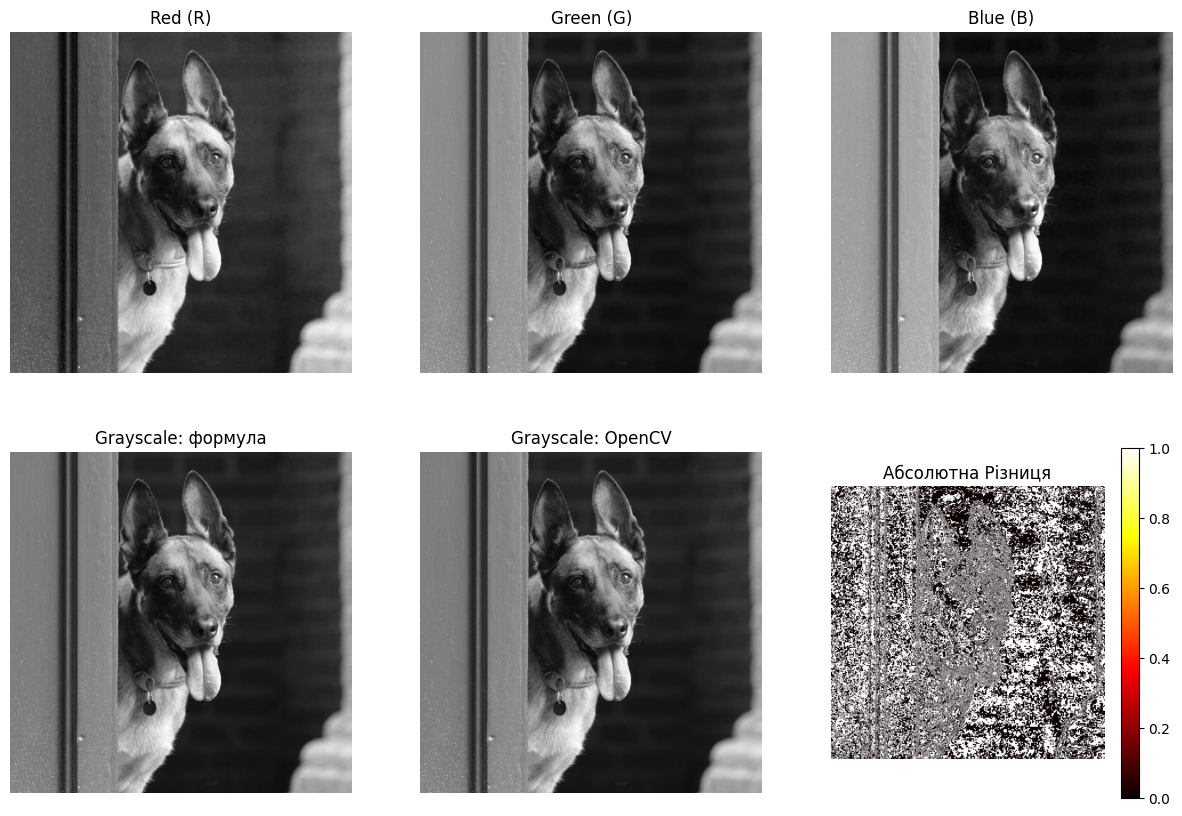

Середня абсолютна різниця: 0.4974


In [7]:
# Прибираємо альфа-канал, якщо він є
image_rgb = image[..., :3] if (image.ndim == 3 and image.shape[-1] == 4) else image

# Перетворення зображення в масив
rgb_array = np.array(image_rgb)

# Виділення каналів
R = rgb_array[:, :, 0]
G = rgb_array[:, :, 1]
B = rgb_array[:, :, 2]

# Виведення каналів
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(R, cmap="gray", vmin=0, vmax=255)
plt.title("Red (R)")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(G, cmap="gray", vmin=0, vmax=255)
plt.title("Green (G)")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(B, cmap="gray", vmin=0, vmax=255)
plt.title("Blue (B)")
plt.axis("off")

# Grayscale за теоретичною формулою
gray_formula = (
    0.299 * R +
    0.587 * G +
    0.114 * B
)

# Перетворення до uint8
gray_formula = gray_formula.astype(np.uint8)

# Grayscale за допомогою вбудованої функції OpenCV
gray_cv2 = cv2.cvtColor(rgb_array, cv2.COLOR_RGB2GRAY)

# Абсолютна різниця між двома результатами
difference = np.abs(
    gray_formula.astype(np.int16) -
    gray_cv2.astype(np.int16)
)

plt.subplot(2, 3, 4)
plt.imshow(gray_formula, cmap="gray", vmin=0, vmax=255)
plt.title("Grayscale: формула")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(gray_cv2, cmap="gray", vmin=0, vmax=255)
plt.title("Grayscale: OpenCV")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(difference, cmap="hot", vmin=0, vmax=difference.max())
plt.title("Абсолютна Різниця")
plt.colorbar()
plt.axis("off")

plt.show()

mean_difference = np.mean(difference)
print(f"Середня абсолютна різниця: {mean_difference:.4f}")


### HSV and YCbCr
Аналогічно розкладаємо картинку за HSV і YCbCr. Зазначимо, зазвичай H (Hue) подається у вигляді кола, а не діапазону значень.

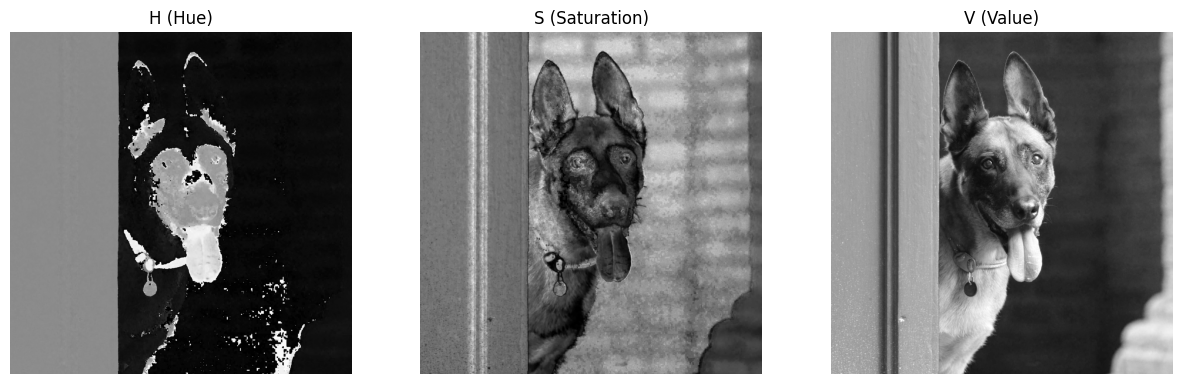

In [8]:
# Перетворення RGB → HSV (вбудована функція OpenCV, для порівняння з формулою нижче)
image_hsv = cv2.cvtColor(rgb_array, cv2.COLOR_RGB2HSV)

H = image_hsv[:, :, 0]
S = image_hsv[:, :, 1]
V = image_hsv[:, :, 2]

# Нормалізація RGB до діапазону [0, 1]
R_norm = R / 255.0
G_norm = G / 255.0
B_norm = B / 255.0

# Мінімальне значення RGB
RGB_min = np.minimum.reduce([R_norm, G_norm, B_norm])

# Обчислення Value (V)
V = np.maximum.reduce([R_norm, G_norm, B_norm])

# 2.2 Обчислення Saturation (S)
S = np.zeros_like(V)

mask = V != 0
S[mask] = (V[mask] - RGB_min[mask]) / V[mask]

# 2.3 Обчислення Hue (H)
H = np.zeros_like(V)

# V = R
mask = (V == R_norm) & (V != RGB_min)
H[mask] = (
    60 * (
        (G_norm[mask] - B_norm[mask]) /
        (V[mask] - RGB_min[mask])
    )
) % 360

# V = G
mask = (V == G_norm) & (V != RGB_min)
H[mask] = 60 * (
    2 +
    (B_norm[mask] - R_norm[mask]) /
    (V[mask] - RGB_min[mask])
)

# V = B
mask = (V == B_norm) & (V != RGB_min)
H[mask] = 60 * (
    4 +
    (R_norm[mask] - G_norm[mask]) /
    (V[mask] - RGB_min[mask])
)

# Виведення HSV
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray", vmin=0, vmax=360)
plt.title("H (Hue)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray", vmin=0, vmax=1)
plt.title("S (Saturation)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray", vmin=0, vmax=1)
plt.title("V (Value)")
plt.axis("off")

plt.show()


MSE RGB → YUV → RGB: 0.000738


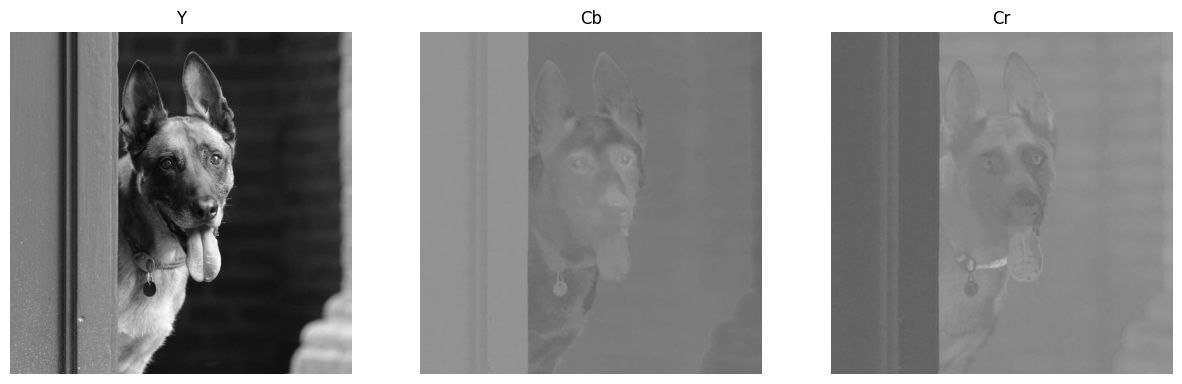

In [9]:
# RGB → YUV (ITU-R BT.601)
Y = (
    0.299 * R_norm +
    0.587 * G_norm +
    0.114 * B_norm
)
U = (
    -0.14713 * R_norm -
    0.28886 * G_norm +
    0.436 * B_norm
)
V = (
    0.615 * R_norm -
    0.51499 * G_norm -
    0.10001 * B_norm
)


# YUV → RGB

R_restored = Y + 1.13983 * V
G_restored = Y - 0.39465 * U - 0.58060 * V
B_restored = Y + 2.03211 * U


# Обмеження значень RGB до діапазону [0, 1]
R_restored = np.clip(R_restored, 0, 1)
G_restored = np.clip(G_restored, 0, 1)
B_restored = np.clip(B_restored, 0, 1)


# Об'єднання відновлених каналів RGB
rgb_restored = np.stack(
    [R_restored, G_restored, B_restored],
    axis=2
)


# Порівняння з початковим RGB
rgb_original = np.stack(
    [R_norm, G_norm, B_norm],
    axis=2
)

difference = np.abs(rgb_original - rgb_restored)

mean_difference = np.mean(difference*255)

print(f"MSE RGB → YUV → RGB: {mean_difference:.6f}")


# Виведення каналів YUV
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(Y, cmap="gray", vmin=0, vmax=1)
plt.title("Y")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(U, cmap="gray", vmin=-0.436, vmax=0.436)
plt.title("Cb")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray", vmin=-0.615, vmax=0.615)
plt.title("Cr")
plt.axis("off")

plt.show()

### Геометричні перетворення: поворот і обрізання

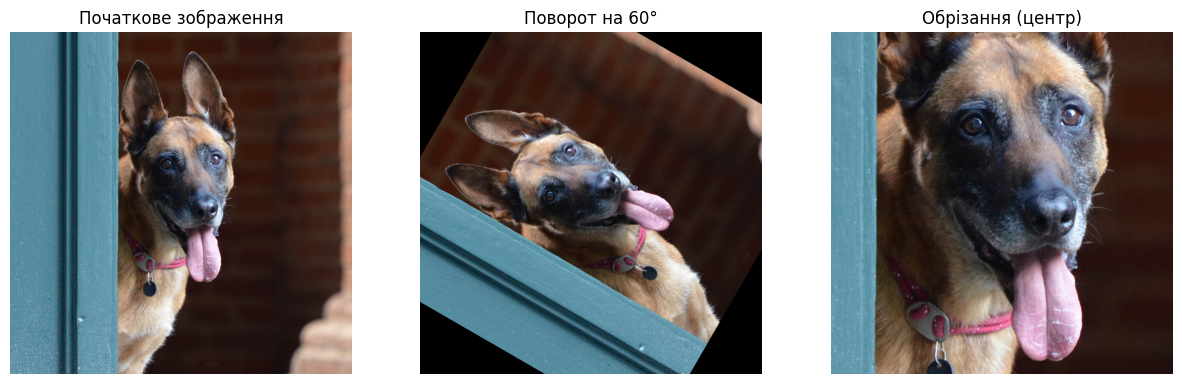

In [10]:
# Поворот зображення на 60° (без розширення меж, як у PIL rotate(expand=False))
(h, w) = image_rgb.shape[:2]
center = (w // 2, h // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 60, 1.0)
rotated = cv2.warpAffine(image_rgb, rotation_matrix, (w, h))

# Обрізання по центру (половина)
crop_width = w // 2
crop_height = h // 2

left = (w - crop_width) // 2
top = (h - crop_height) // 2
right = left + crop_width
bottom = top + crop_height
cropped = image_rgb[top:bottom, left:right]


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Початкове зображення")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(rotated)
plt.title("Поворот на 60°")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cropped)
plt.title("Обрізання (центр)")
plt.axis("off")

plt.show()


### Методи Інтерполяції
Зменшуємо/збільшуємо в 4 рази і порівнюємо NEAREST, LINEAR, CUBIC, LANCZOS4.

Результати порівняння інтерполяції:

NEAREST:  34.85 dB
LINEAR:   36.55 dB
CUBIC:    37.81 dB
LANCZOS:  38.02 dB


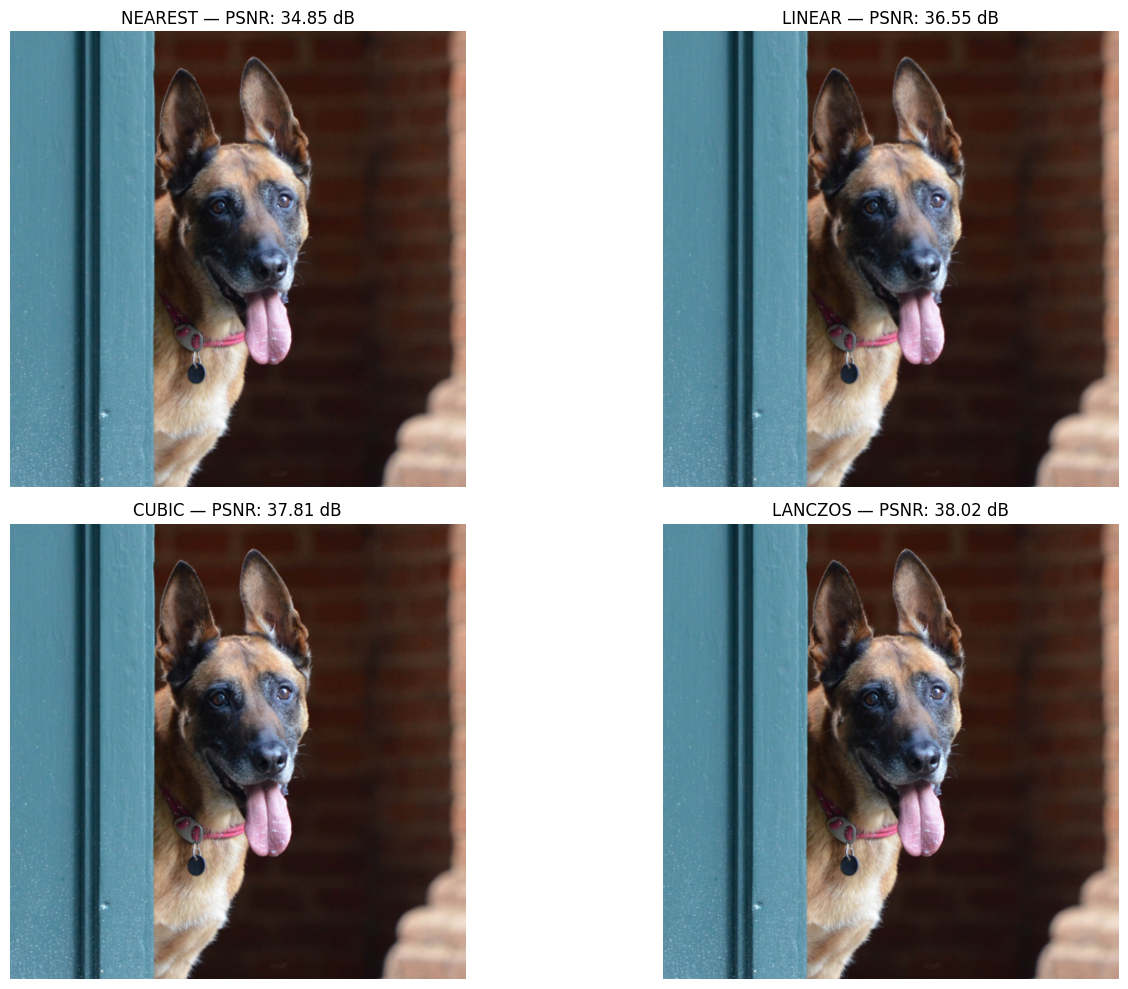

In [14]:
import numpy as np

original = image_rgb
height, width = original.shape[:2]

# Зменшення
small = cv2.resize(
    original,
    (width // 4, height // 4),
    interpolation=cv2.INTER_AREA
)

# Функція для обчислення PSNR
def calculate_psnr(original, restored):
    original_array = np.array(original).astype(np.float64)
    restored_array = np.array(restored).astype(np.float64)

    mse = np.mean((original_array - restored_array) ** 2)
    if mse == 0:
        return float("inf")
    
    return 10 * np.log10((255 ** 2) / mse)


# Відновлення до початкового розміру різними методами
nearest = cv2.resize(small, (width, height), interpolation=cv2.INTER_NEAREST)
linear = cv2.resize(small, (width, height), interpolation=cv2.INTER_LINEAR)
cubic = cv2.resize(small, (width, height), interpolation=cv2.INTER_CUBIC)
lanczos = cv2.resize(small, (width, height), interpolation=cv2.INTER_LANCZOS4)

# Обчислення PSNR
psnr_nearest = calculate_psnr(original, nearest)
psnr_linear = calculate_psnr(original, linear)
psnr_cubic = calculate_psnr(original, cubic)
psnr_lanczos = calculate_psnr(original, lanczos)


# Виведення PSNR
print("Результати порівняння інтерполяції:\n")

print(f"NEAREST:  {psnr_nearest:.2f} dB")
print(f"LINEAR:   {psnr_linear:.2f} dB")
print(f"CUBIC:    {psnr_cubic:.2f} dB")
print(f"LANCZOS:  {psnr_lanczos:.2f} dB")


# Виведення відновлених зображень
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(nearest)
plt.title(f"NEAREST — PSNR: {psnr_nearest:.2f} dB")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(linear)
plt.title(f"LINEAR — PSNR: {psnr_linear:.2f} dB")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(cubic)
plt.title(f"CUBIC — PSNR: {psnr_cubic:.2f} dB")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(lanczos)
plt.title(f"LANCZOS — PSNR: {psnr_lanczos:.2f} dB")
plt.axis("off")

plt.tight_layout()
plt.show()


### Метрики Якості MSE, RMSE, PSNR, SSIM

Порівняння метрик:

MSE:
  Вручну:       98.430232
  Вбудована:    98.430232

RMSE:
  Вручну:       9.921201
  Вбудована:    9.921201

PSNR:
  Вручну:       28.199519 dB
  Вбудована:    28.199519 dB
SSIM: 0.482157


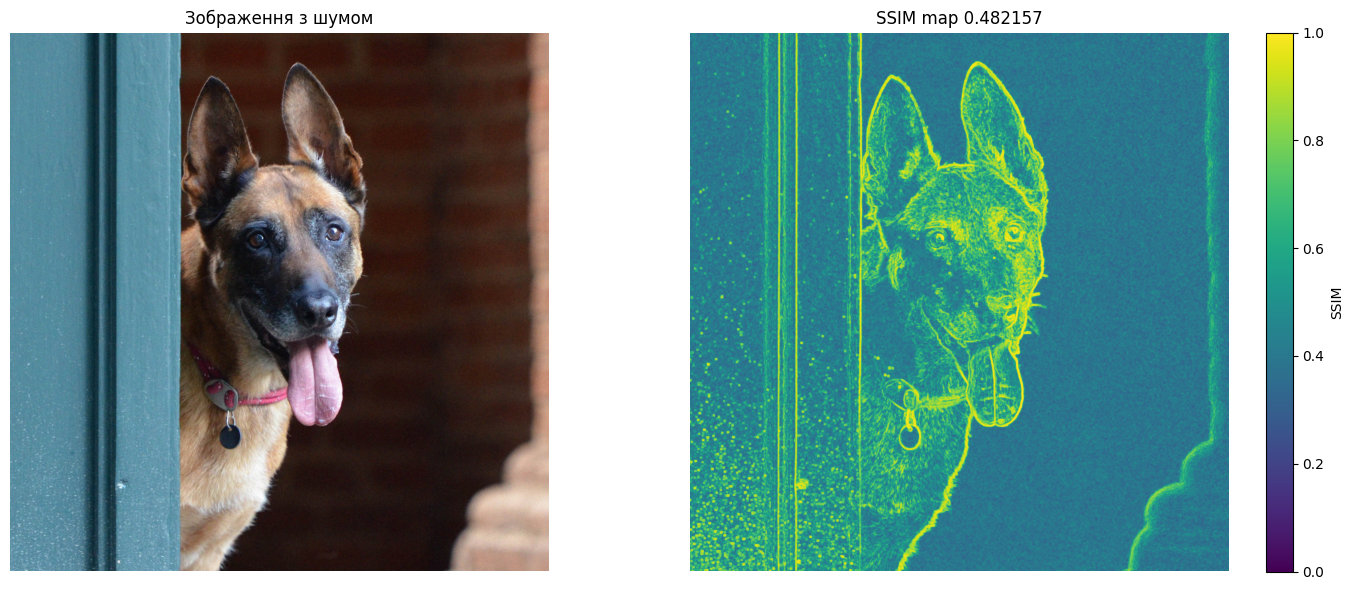

In [15]:
from skimage.metrics import (
    mean_squared_error,
    peak_signal_noise_ratio,
    structural_similarity
)

original = image_rgb.astype(np.float64)
np.random.seed(42)

noise = np.random.normal(
    loc=0,
    scale=10,
    size=original.shape
)

noisy = original + noise
noisy = np.clip(noisy, 0, 255)

# Функції вручну
mse_manual = np.mean(
    (original - noisy) ** 2
)

rmse_manual = np.sqrt(mse_manual)

psnr_manual = 10 * np.log10(
    (255 ** 2) / mse_manual
)

# Функції вбудовані
mse_builtin = mean_squared_error(
    original,
    noisy
)

rmse_builtin = np.sqrt(mean_squared_error(original, noisy))

psnr_builtin = peak_signal_noise_ratio(
    original,
    noisy,
    data_range=255
)

print("Порівняння метрик:\n")

print(f"MSE:")
print(f"  Вручну:       {mse_manual:.6f}")
print(f"  Вбудована:    {mse_builtin:.6f}")

print(f"\nRMSE:")
print(f"  Вручну:       {rmse_manual:.6f}")
print(f"  Вбудована:    {rmse_builtin:.6f}")

print(f"\nPSNR:")
print(f"  Вручну:       {psnr_manual:.6f} dB")
print(f"  Вбудована:    {psnr_builtin:.6f} dB")

ssim, ssim_map = structural_similarity(
    original.astype(np.uint8),
    noisy.astype(np.uint8),
    channel_axis=2,
    data_range=255,
    full=True
)

# Один SSIM на кожен піксель
ssim_map = np.mean(ssim_map, axis=2)

# Для коректного відображення
ssim_map_display = np.clip(ssim_map, 0, 1)

print(f"SSIM: {ssim:.6f}")

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(noisy.astype(np.uint8))
plt.title("Зображення з шумом")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ssim_map_display, cmap="viridis", vmin=0, vmax=1)
plt.title(f"SSIM map {ssim:.6f}")
plt.colorbar(label="SSIM")
plt.axis("off")

plt.tight_layout()
plt.show()


### JPEG-компресія

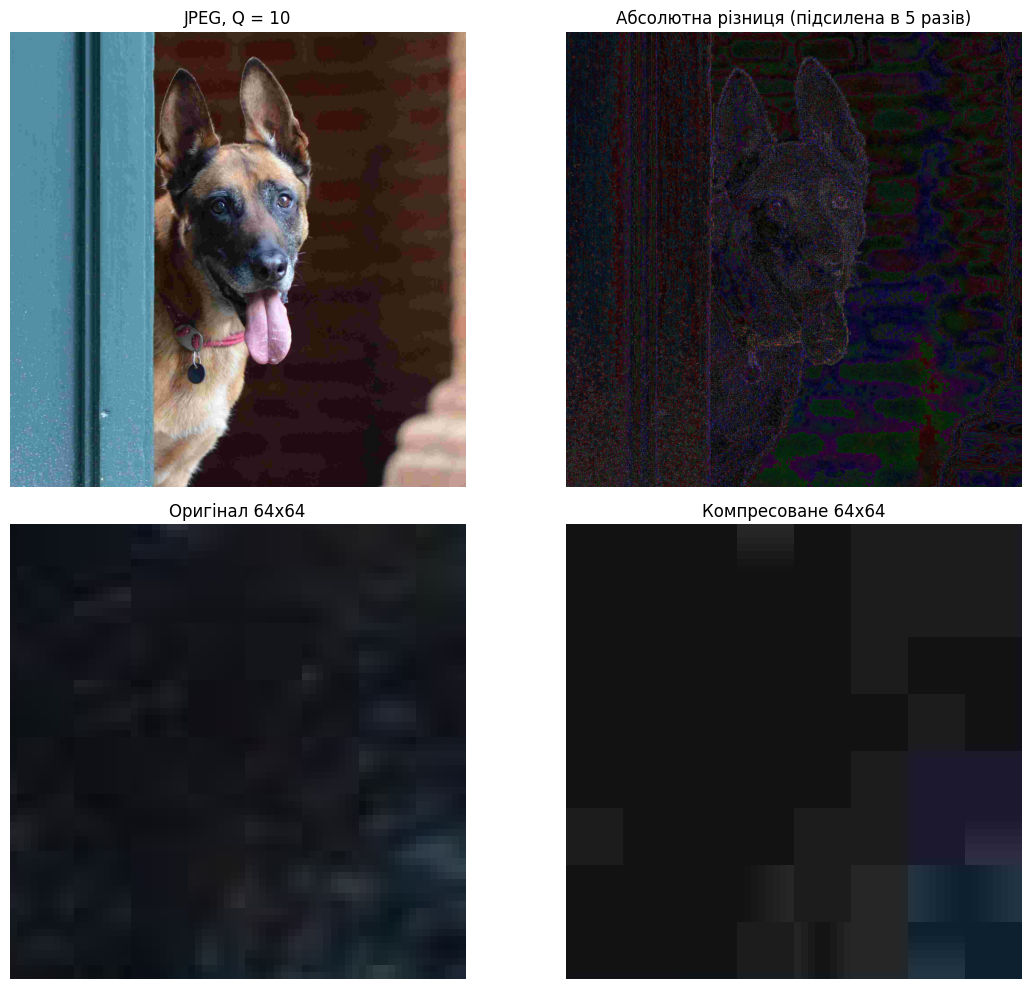

Результати JPEG-компресії:

Q       Size (KB)      PSNR (dB)      SSIM           
-----------------------------------------------------
10      77.80          31.9308        0.858882       
20      102.52         35.5665        0.913248       
40      148.33         38.9938        0.948478       
60      198.54         40.6631        0.961497       
80      314.12         43.0243        0.975110       
95      742.49         47.0022        0.988063       


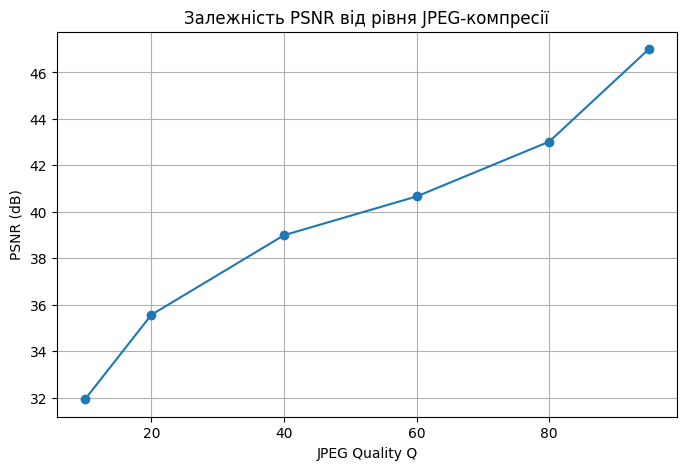

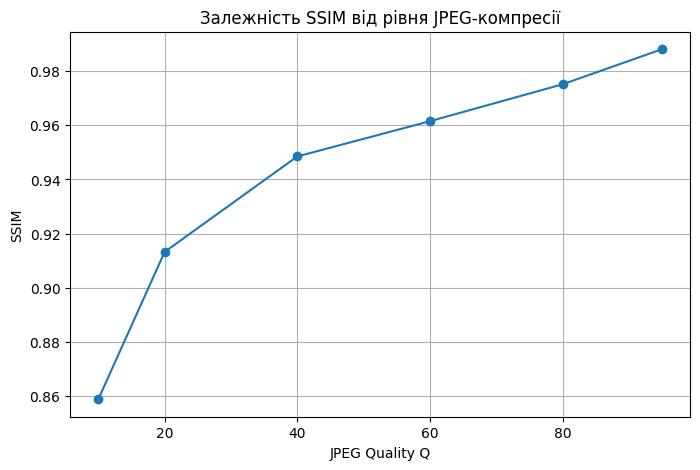

In [16]:
original_image = image_rgb
qualities = [10, 20, 40, 60, 80, 95]

results = []
compressed_images = {}

original_image_bgr = cv2.cvtColor(original_image, cv2.COLOR_RGB2BGR)

for Q in qualities:
    file_name = f"puppy_Q{Q}.jpg"
    
    cv2.imwrite(
        file_name,
        original_image_bgr,
        [cv2.IMWRITE_JPEG_QUALITY, Q]
    )
    
    compressed_image_bgr = cv2.imread(file_name, cv2.IMREAD_COLOR)
    compressed_image = cv2.cvtColor(compressed_image_bgr, cv2.COLOR_BGR2RGB)
    compressed = compressed_image.astype(np.float64)
    
    file_size_kb = os.path.getsize(file_name) / 1024
    
    psnr = peak_signal_noise_ratio(
        original,
        compressed,
        data_range=255
    )
    
    ssim = structural_similarity(
        original.astype(np.uint8),
        compressed.astype(np.uint8),
        channel_axis=2,
        data_range=255
    )
    
    results.append([Q, file_size_kb, psnr, ssim])
    compressed_images[Q] = compressed_image


# Графіки для Q10: граф, різниця (посилена в 5 разів),
# і порівняння 64х64 частин.

compressed_q10 = compressed_images[10].astype(np.float64)

difference = np.abs(original - compressed_q10)

difference_amplified = np.clip(
    difference * 5,
    0,
    255
).astype(np.uint8)


# 64x64
height, width = original.shape[:2]

center_x = width // 2
center_y = height // 2
half = 32

original_crop = original_image[
    center_y - half:center_y + half,
    center_x - half:center_x + half
]

compressed_crop = compressed_images[10][
    center_y - half:center_y + half,
    center_x - half:center_x + half
]


plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(compressed_images[10])
plt.title("JPEG, Q = 10")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(difference_amplified)
plt.title("Абсолютна різниця (підсилена в 5 разів)")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(original_crop)
plt.title("Оригінал 64х64")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(compressed_crop)
plt.title("Компресоване 64х64")
plt.axis("off")

plt.tight_layout()
plt.show()


print("Результати JPEG-компресії:\n")
print(
    f"{'Q':<8}"
    f"{'Size (KB)':<15}"
    f"{'PSNR (dB)':<15}"
    f"{'SSIM':<15}"
)
print("-" * 53)

for Q, size, psnr, ssim in results:
    print(
        f"{Q:<8}"
        f"{size:<15.2f}"
        f"{psnr:<15.4f}"
        f"{ssim:<15.6f}"
    )

Q_values = [row[0] for row in results]
sizes = [row[1] for row in results]
psnr_values = [row[2] for row in results]
ssim_values = [row[3] for row in results]

plt.figure(figsize=(8, 5))

plt.plot(Q_values, psnr_values, marker="o")
plt.xlabel("JPEG Quality Q")
plt.ylabel("PSNR (dB)")
plt.title("Залежність PSNR від рівня JPEG-компресії")
plt.grid(True)

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(Q_values, ssim_values, marker="o")
plt.xlabel("JPEG Quality Q")
plt.ylabel("SSIM")
plt.title("Залежність SSIM від рівня JPEG-компресії")
plt.grid(True)

plt.show()


## Висновки
- При якому рівні компресії втрата якості стає суттєвою?  
Для компресій Q10-Q20 PSNR значно нижчий за 0.4 - втрата якості достатньо помітна.  
Для Q40+ якість достатньо хороша (по розміру бачимо, що вони близькі або навіть більші за 260Кб - стандартний розмір JPEG обраний програмою під час перетворення BMP → JPG).

- Чи однаково змінюються PSNR та SSIM?  
Обидва значення зростають з ростом якості, але не рівномірно, оскільки PSNR відслідковує числову різницю між пікселями, а SSIM - структурну схожість. На нашому прикладі бачимо що навіть на відносно низьких Q (40/60), SSIM зберігає високу структурність - ми все ще достатньо чітко бачимо пса, стіни і тп. Тоді як різниця між самими пікселями вже достатньо серйозна аби PSNR був помітно нижчий від скажімо Q(80/95).

- Який колірний простір краще підходить для певного типу обробки?  
RGB дозволяє обробляти кожен з 3 основних каналів кольору окремо, що зручно для цифрових платформ.  
HSV зручний для роботи з самим кольором (по saturation/value).  
YCbCr передає яскравість і колір окремо, добре підходить для стиснення зображень.

- Як зміна роздільної здатності впливає на якість?
Безповоротньо втрачається частина інформації. Роздільність можна відновити методами інтерполяції, але навіть так якість значно впаде. Різні методи по різному впливають на якість.